In [1]:
!pip install requests

In [2]:
import requests
import csv
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [3]:
API_KEY = "0a4ef3270efc77fa7b4a6f3bc132e854"  
BASE_URL = "https://api.themoviedb.org/3/discover/movie"
GENRE_URL = "https://api.themoviedb.org/3/genre/movie/list"
POSTER_BASE_URL = "https://image.tmdb.org/t/p/w500"

# Функция для получения справочника жанров
def fetch_genres():
    params = {
        "api_key": API_KEY,
        "language": "en-US",
    }
    response = requests.get(GENRE_URL, params=params)
    if response.status_code == 200:
        genres = response.json().get("genres", [])
        return {genre["id"]: genre["name"] for genre in genres}
    else:
        print(f"Error fetching genres: {response.status_code}")
        return {}

# Функция для получения фильмов с разными критериями сортировки
def fetch_movies(criteria, num_pages=50):
    all_movies = []
    for page in range(1, num_pages + 1):
        params = {
            "api_key": API_KEY,
            "language": "en-US",
            "sort_by": criteria,
            "page": page,
        }
        response = requests.get(BASE_URL, params=params)
        if response.status_code == 200:
            all_movies.extend(response.json().get("results", []))
        else:
            print(f"Error fetching page {page}: {response.status_code}")
            break
    return all_movies

# Получение справочника жанров
genres_dict = fetch_genres()

# Список критериев сортировки для увеличения количества фильмов
sorting_criteria = ["popularity.desc", "release_date.desc", "vote_average.desc", "revenue.desc", "original_title.asc"]

# Сбор всех фильмов
movies_data = []
for criteria in sorting_criteria:
    movies = fetch_movies(criteria, num_pages=20)  # 20 страниц на критерий = 400 фильмов
    for movie in movies:
        # Преобразование жанров в текстовые названия
        genre_ids = movie.get("genre_ids", [])
        genres = [genres_dict.get(genre_id, "Unknown") for genre_id in genre_ids]
        
        movie_details = {
            "Title": movie.get("title"),
            "Genres": ", ".join(genres),  # Преобразование списка жанров в строку
            "Release Year": movie.get("release_date", "").split("-")[0] if movie.get("release_date") else "N/A",
            "IMDb Rating": movie.get("vote_average"),
            "Number of User Votes": movie.get("vote_count"),
            "Description": movie.get("overview"),
            "Poster URL": f"{POSTER_BASE_URL}{movie.get('poster_path')}" if movie.get("poster_path") else "N/A",
        }
        if movie_details not in movies_data:  # Убираем дубликаты
            movies_data.append(movie_details)

# Проверка количества фильмов
print(f"Total movies fetched: {len(movies_data)}")

# Запись в CSV
csv_file_path = "movies_data_with_genres.csv"
csv_columns = ["Title", "Genres", "Release Year", "IMDb Rating", "Number of User Votes", "Description", "Poster URL"]

try:
    with open(csv_file_path, mode="w", encoding="utf-8", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=csv_columns)
        writer.writeheader()
        writer.writerows(movies_data)
    print(f"Data successfully saved to file {csv_file_path}")
except Exception as e:
    print(f"An error occurred while saving data: {e}")

Total movies fetched: 1892
Data successfully saved to file movies_data_with_genres.csv


In [7]:
csv_file_path = "movies_data_with_genres.csv"
data = pd.read_csv(csv_file_path)
data

,Title,Genres,Release Year,IMDb Rating,Number of User Votes,Description,Poster URL
0,Venom: The Last Dance,"Action, Science Fiction, Adventure",2024.0,6.7,1233,Eddie and Venom are on the run. Hunted by both...,https://image.tmdb.org/t/p/w500/aosm8NMQ3UyoBV...
1,Moana 2,"Animation, Adventure, Family, Comedy",2024.0,6.9,436,After receiving an unexpected call from her wa...,https://image.tmdb.org/t/p/w500/yh64qw9mgXBvla...
2,Elevation,"Action, Science Fiction, Thriller",2024.0,6.4,128,A single father and two women venture from the...,https://image.tmdb.org/t/p/w500/uQhYBxOVFU6s9a...
3,Absolution,"Action, Crime, Thriller",2024.0,6.0,121,An aging ex-boxer gangster working as muscle f...,https://image.tmdb.org/t/p/w500/cNtAslrDhk1i3I...
4,Armor,"Action, Crime, Thriller",2024.0,5.6,55,Armored truck security guard James Brody is wo...,https://image.tmdb.org/t/p/w500/pnXLFioDeftqjl...
...,...,...,...,...,...,...,...
1887,#FORUM,Documentary,2012.0,0.0,0,"#FORUM presented by Special Blend, Forum, Four...",https://image.tmdb.org/t/p/w500/dK2atwk558POON...
1888,#FreeBelarus,NaN,2020.0,0.0,0,Dedicated to all Belarusians and those who are...,https://image.tmdb.org/t/p/w500/eAeDTtq0szDIQu...
1889,#FTM,NaN,NaN,0.0,0,NaN,NaN
1890,#FullMethod,NaN,2019.0,0.0,0,Preparing to play a serial killer for a new te...,https://image.tmdb.org/t/p/w500/eGEIgjCIRqjPhK...


In [9]:
missing_values = data.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 Title                     0
Genres                  230
Release Year            101
IMDb Rating               0
Number of User Votes      0
Description             266
Poster URL              300
dtype: int64


In [11]:
data['Release Year'] = data['Release Year'].fillna(data['Release Year'].mode()[0])
data.dropna(subset=['Genres', 'Description', 'Poster URL'], inplace=True) #Remove rows with missing Price or Location
data.drop_duplicates()
data

,Title,Genres,Release Year,IMDb Rating,Number of User Votes,Description,Poster URL
0,Venom: The Last Dance,"Action, Science Fiction, Adventure",2024.0,6.7,1233,Eddie and Venom are on the run. Hunted by both...,https://image.tmdb.org/t/p/w500/aosm8NMQ3UyoBV...
1,Moana 2,"Animation, Adventure, Family, Comedy",2024.0,6.9,436,After receiving an unexpected call from her wa...,https://image.tmdb.org/t/p/w500/yh64qw9mgXBvla...
2,Elevation,"Action, Science Fiction, Thriller",2024.0,6.4,128,A single father and two women venture from the...,https://image.tmdb.org/t/p/w500/uQhYBxOVFU6s9a...
3,Absolution,"Action, Crime, Thriller",2024.0,6.0,121,An aging ex-boxer gangster working as muscle f...,https://image.tmdb.org/t/p/w500/cNtAslrDhk1i3I...
4,Armor,"Action, Crime, Thriller",2024.0,5.6,55,Armored truck security guard James Brody is wo...,https://image.tmdb.org/t/p/w500/pnXLFioDeftqjl...
...,...,...,...,...,...,...,...
1882,#FollowMe,"Horror, Thriller",2019.0,4.5,15,"Three British women from London, consisting of...",https://image.tmdb.org/t/p/w500/sApRum4ZZBLkcu...
1883,#followme,Documentary,2019.0,7.0,3,Reporter Nicolaas Veul decides to set up his f...,https://image.tmdb.org/t/p/w500/qEtUVTt6OiUCA6...
1884,#Followme II,Horror,2024.0,0.0,0,After three British women went missing from a ...,https://image.tmdb.org/t/p/w500/ngdzoE84cIcwR1...
1887,#FORUM,Documentary,2012.0,0.0,0,"#FORUM presented by Special Blend, Forum, Four...",https://image.tmdb.org/t/p/w500/dK2atwk558POON...


In [13]:
missing_values = data.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 Title                   0
Genres                  0
Release Year            0
IMDb Rating             0
Number of User Votes    0
Description             0
Poster URL              0
dtype: int64


In [15]:
categorical_variables = data.select_dtypes(include=['object', 'category']).columns #here selected columns with cat. var.(object and category)
numeric_variables = data.select_dtypes(include=['float64', 'int64']).columns #here selected columns with num. var.(int., float)
print('cat variables:', categorical_variables)
print('num variables:', numeric_variables)

cat variables: Index(['Title', 'Genres', 'Description', 'Poster URL'], dtype='object')
num variables: Index(['Release Year', 'IMDb Rating', 'Number of User Votes'], dtype='object')


In [17]:
scaler = StandardScaler() #use the StandardScaler 
numeric_variables = data.select_dtypes(include=['float64', 'int64']).columns
data[numeric_variables] = scaler.fit_transform(data[numeric_variables]) #calculate SS for Prodict_ID column that computer understood it
data

,Title,Genres,Release Year,IMDb Rating,Number of User Votes,Description,Poster URL
0,Venom: The Last Dance,"Action, Science Fiction, Adventure",0.587404,0.207224,-0.422870,Eddie and Venom are on the run. Hunted by both...,https://image.tmdb.org/t/p/w500/aosm8NMQ3UyoBV...
1,Moana 2,"Animation, Adventure, Family, Comedy",0.587404,0.269249,-0.542871,After receiving an unexpected call from her wa...,https://image.tmdb.org/t/p/w500/yh64qw9mgXBvla...
2,Elevation,"Action, Science Fiction, Thriller",0.587404,0.114187,-0.589245,A single father and two women venture from the...,https://image.tmdb.org/t/p/w500/uQhYBxOVFU6s9a...
3,Absolution,"Action, Crime, Thriller",0.587404,-0.009863,-0.590299,An aging ex-boxer gangster working as muscle f...,https://image.tmdb.org/t/p/w500/cNtAslrDhk1i3I...
4,Armor,"Action, Crime, Thriller",0.587404,-0.133913,-0.600236,Armored truck security guard James Brody is wo...,https://image.tmdb.org/t/p/w500/pnXLFioDeftqjl...
...,...,...,...,...,...,...,...
1882,#FollowMe,"Horror, Thriller",0.179265,-0.475051,-0.606259,"Three British women from London, consisting of...",https://image.tmdb.org/t/p/w500/sApRum4ZZBLkcu...
1883,#followme,Documentary,0.179265,0.300262,-0.608065,Reporter Nicolaas Veul decides to set up his f...,https://image.tmdb.org/t/p/w500/qEtUVTt6OiUCA6...
1884,#Followme II,Horror,0.587404,-1.870613,-0.608517,After three British women went missing from a ...,https://image.tmdb.org/t/p/w500/ngdzoE84cIcwR1...
1887,#FORUM,Documentary,-0.392130,-1.870613,-0.608517,"#FORUM presented by Special Blend, Forum, Four...",https://image.tmdb.org/t/p/w500/dK2atwk558POON...


In [19]:
label_encoder = LabelEncoder() #create oиject LabelEncoder
for column in categorical_variables: # a loop begins all columns specified in the cat. var. 
    data[column] = label_encoder.fit_transform(data[column]) #tranforms all  text values in num codes and saves it
data.head(31)#print

,Title,Genres,Release Year,IMDb Rating,Number of User Votes,Description,Poster URL
0,1202,63,0.587404,0.207224,-0.422870,513,366
1,704,138,0.587404,0.269249,-0.542871,271,1225
2,412,66,0.587404,0.114187,-0.589245,167,1065
3,200,41,0.587404,-0.009863,-0.590299,316,425
4,236,41,0.587404,-0.133913,-0.600236,359,914
5,868,230,0.587404,0.176212,-0.599483,461,628
6,481,19,0.587404,0.207224,-0.454639,1256,40
7,1215,194,0.587404,0.517349,-0.601591,969,115
8,693,130,0.587404,0.796462,-0.603097,1105,161
9,1133,129,0.587404,0.734437,-0.099907,246,1132


In [21]:
data.drop_duplicates()
data

,Title,Genres,Release Year,IMDb Rating,Number of User Votes,Description,Poster URL
0,1202,63,0.587404,0.207224,-0.422870,513,366
1,704,138,0.587404,0.269249,-0.542871,271,1225
2,412,66,0.587404,0.114187,-0.589245,167,1065
3,200,41,0.587404,-0.009863,-0.590299,316,425
4,236,41,0.587404,-0.133913,-0.600236,359,914
...,...,...,...,...,...,...,...
1882,160,400,0.179265,-0.475051,-0.606259,1089,996
1883,170,260,0.179265,0.300262,-0.608065,880,927
1884,161,373,0.587404,-1.870613,-0.608517,288,840
1887,153,260,-0.392130,-1.870613,-0.608517,16,465


In [23]:
# Display the first few rows of the dataset
print("Dataset Preview:")
print(data.head())

# --- 1. Statistical Analysis ---
print("\n--- Statistical Analysis ---")
# Basic statistics
print(data.describe())

# Calculate the mean and median for numerical features
mean_ratings = data['IMDb Rating'].mean()
median_ratings = data['IMDb Rating'].median()
print(f"Mean Ratings: {mean_ratings}")
print(f"Median Ratings: {median_ratings}")



Dataset Preview:
   Title  Genres  Release Year  IMDb Rating  Number of User Votes  \
0   1202      63      0.587404     0.207224             -0.422870   
1    704     138      0.587404     0.269249             -0.542871   
2    412      66      0.587404     0.114187             -0.589245   
3    200      41      0.587404    -0.009863             -0.590299   
4    236      41      0.587404    -0.133913             -0.600236   

   Description  Poster URL  
0          513         366  
1          271        1225  
2          167        1065  
3          316         425  
4          359         914  

--- Statistical Analysis ---
             Title       Genres  Release Year   IMDb Rating  \
count  1290.000000  1290.000000  1.290000e+03  1.290000e+03   
mean    633.681395   244.541860 -5.486051e-15 -4.406467e-17   
std     366.271299   142.280736  1.000388e+00  1.000388e+00   
min       0.000000     0.000000 -9.616078e+00 -1.870613e+00   
25%     317.250000   121.250000 -2.288744e-01 -1.


Visualizing most common movie genres...


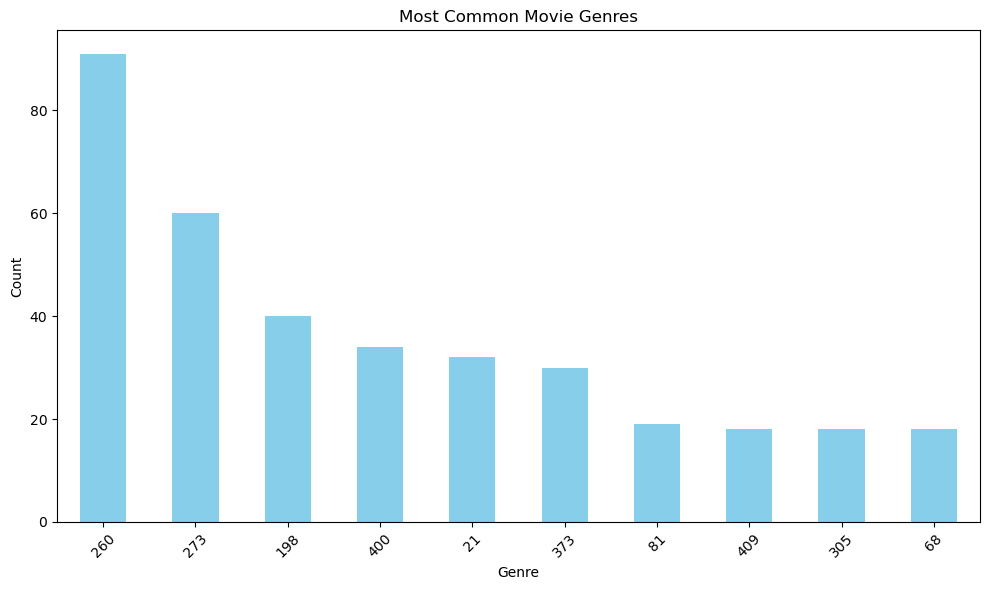

In [25]:
# (a) Most common movie genres
print("\nVisualizing most common movie genres...")
plt.figure(figsize=(10, 6))
data['Genres'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title("Most Common Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Visualizing trends in movie releases over time...


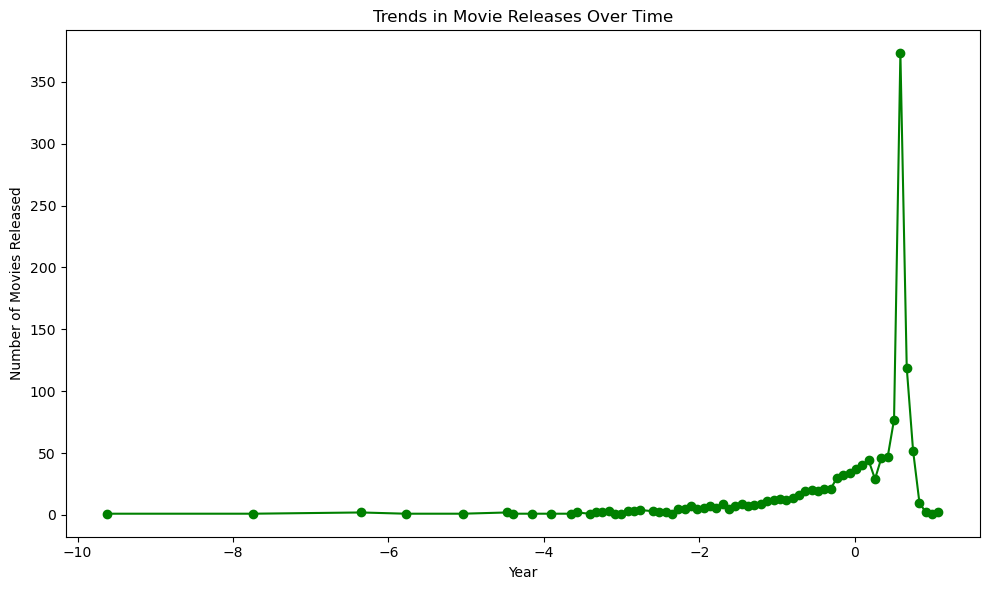

In [26]:
# (b) Trends in movie releases over time
print("Visualizing trends in movie releases over time...")
plt.figure(figsize=(10, 6))
data['Release Year'].value_counts().sort_index().plot(kind='line', marker='o', color='green')
plt.title("Trends in Movie Releases Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Movies Released")
plt.tight_layout()
plt.show()

Visualizing distribution of ratings...


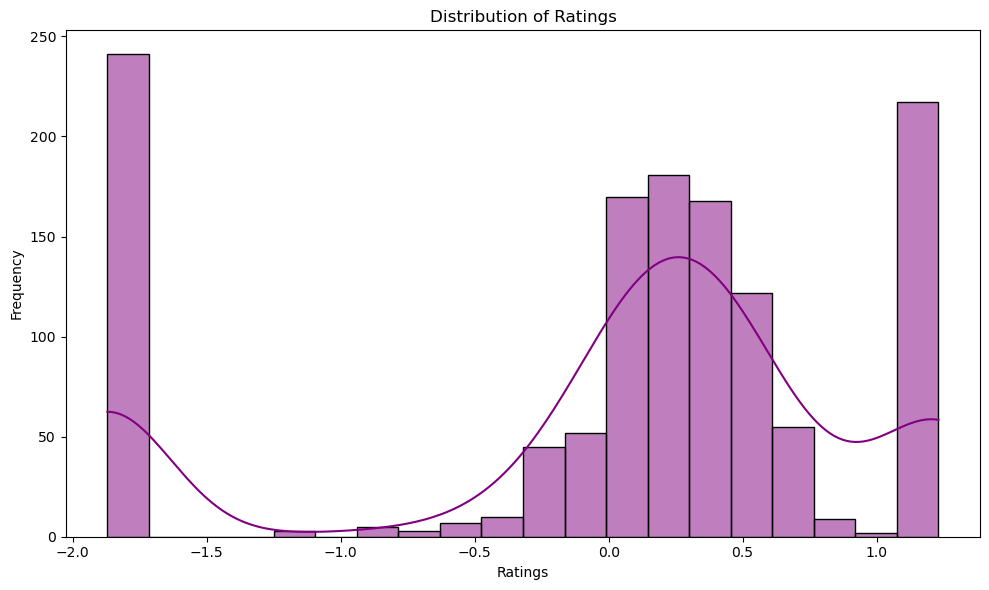

In [27]:
# (c) Distribution of ratings
print("Visualizing distribution of ratings...")
plt.figure(figsize=(10, 6))
sns.histplot(data['IMDb Rating'], kde=True, color='purple', bins=20)
plt.title("Distribution of Ratings")
plt.xlabel("Ratings")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

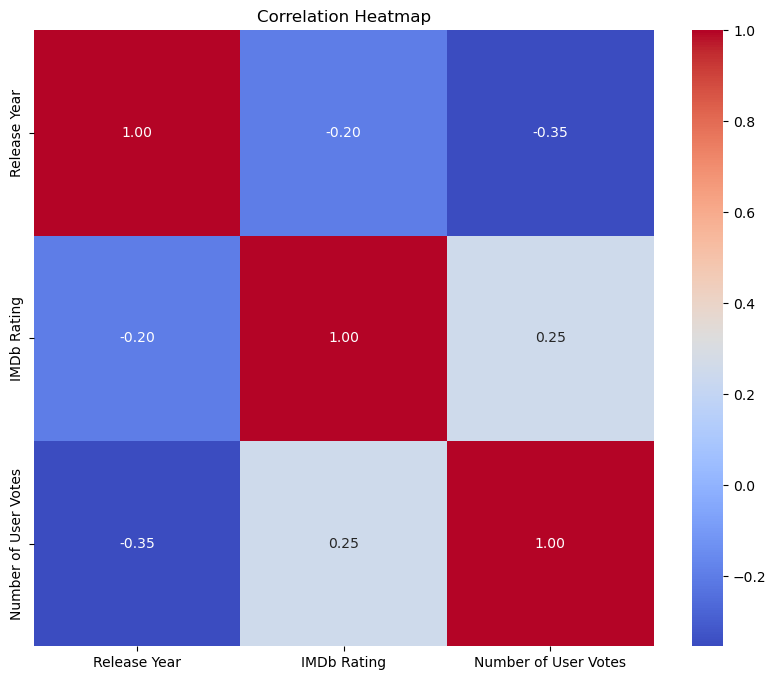

In [29]:
numerical_features = data.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
correlation_matrix = numerical_features.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.show()


In [31]:
X = data[['Release Year', 'Number of User Votes', 'Genres']]  # Features
y = data['IMDb Rating']  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the features (standardize)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict the ratings on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model using RMSE, MAE, and R² score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print performance metrics
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R² Score: {r2}")

Root Mean Squared Error (RMSE): 0.9717725725924198
Mean Absolute Error (MAE): 0.7051013468112493
R² Score: 0.10095562124787938


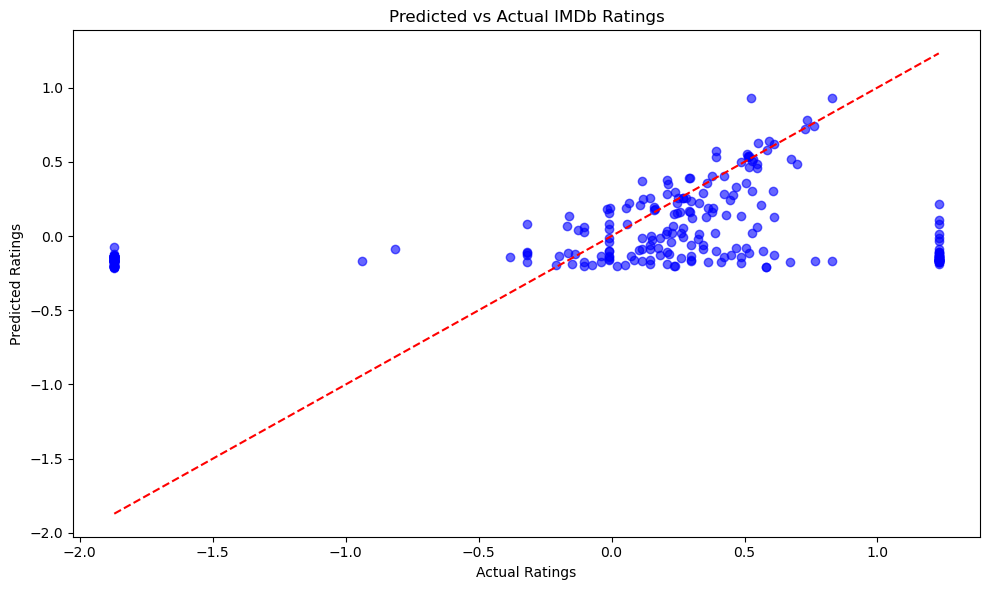

In [33]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title("Predicted vs Actual IMDb Ratings")
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.tight_layout()
plt.show()

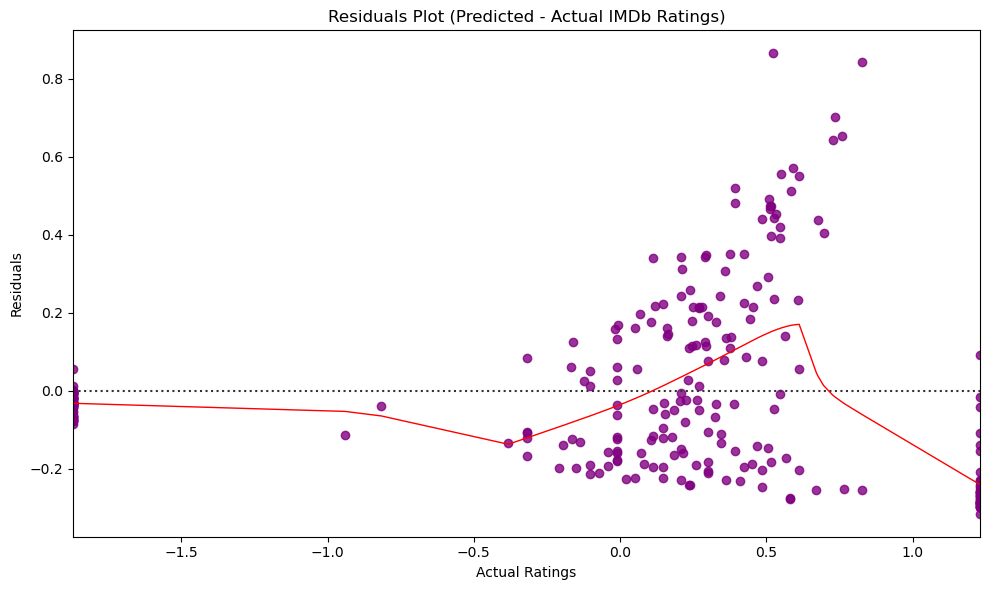

In [34]:
plt.figure(figsize=(10, 6))
sns.residplot(x=y_test, y=y_pred, lowess=True, color='purple', line_kws={'color': 'red', 'lw': 1})
plt.title("Residuals Plot (Predicted - Actual IMDb Ratings)")
plt.xlabel("Actual Ratings")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

In [37]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Загрузка датасета
movies_df = pd.read_csv('movies_data_with_genres.csv')  # Замените 'movies.csv' на путь к вашему файлу

# Проверяем и заполняем пропуски в жанрах и описании
movies_df['Genres'] = movies_df['Genres'].fillna('')
movies_df['Description'] = movies_df['Description'].fillna('')

# Объединяем жанры и описание в один текстовый столбец
movies_df['combined'] = movies_df['Genres'] + " " + movies_df['Description']

# Функция для рекомендаций
def recommend_movies(movie_title, movies_df, top_n=5):
    """
    Рекомендует фильмы на основе жанров и описания.
    
    :param movie_title: Название фильма, для которого ищем рекомендации.
    :param movies_df: Таблица с фильмами.
    :param top_n: Количество фильмов для рекомендации.
    :return: Список рекомендованных фильмов с их характеристиками.
    """
    # Проверяем, есть ли фильм в базе
    if movie_title not in movies_df['Title'].values:
        return f"Фильм '{movie_title}' не найден в базе данных."
    
    # TF-IDF для анализа текста
    tfidf = TfidfVectorizer(stop_words='english')
    tfidf_matrix = tfidf.fit_transform(movies_df['combined'])
    
    # Матрица сходства
    similarity_matrix = cosine_similarity(tfidf_matrix)
    
    # Находим индекс входного фильма
    movie_index = movies_df.index[movies_df['Title'] == movie_title][0]
    
    # Находим индексы похожих фильмов
    similar_indices = similarity_matrix[movie_index].argsort()[::-1][1:top_n+1]
    
    # Формируем список рекомендаций
    recommendations = movies_df.iloc[similar_indices][['Title', 'Genres', 'IMDb Rating', 'Release Year']]
    return recommendations
while True:
    movie_to_search = input("Введите название фильма для рекомендаций (или 'exit' для выхода): ").strip()
    
    if movie_to_search.lower() == 'exit':
        print("Программа завершена.")
        break
    
    recommendations = recommend_movies(movie_to_search, movies_df)
    
    if isinstance(recommendations, str):  # Если фильм не найден
        print(recommendations)
    else:
        print(f"\nРекомендации для '{movie_to_search}':")
        print(recommendations)
        print()

Введите название фильма для рекомендаций (или 'exit' для выхода):  Moana 2



Рекомендации для 'Moana 2':
                                                  Title  \
1104  Burghy: Le avventure di Mr. Burghy, Freddy e P...   
1128                                        I Piramolli   
766                      O psie, który jeździł koleją 2   
1092                                            Breogán   
750                                       Sin cobertura   

                                  Genres  IMDb Rating  Release Year  
1104        Animation, Adventure, Family         10.0        1995.0  
1128        Animation, Adventure, Family         10.0        2004.0  
766                    Family, Adventure          0.0        2025.0  
1092                   Comedy, Adventure         10.0        2024.0  
750   Comedy, Family, Adventure, Fantasy          0.0        2025.0  



Введите название фильма для рекомендаций (или 'exit' для выхода):  exit


Программа завершена.


In [41]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Загрузка датасета
movies_df = pd.read_csv('movies_data_with_genres.csv')  # Замените 'movies_data_with_genres.csv' на путь к вашему файлу

# Проверяем и заполняем пропуски в жанрах и описании
movies_df['Genres'] = movies_df['Genres'].fillna('')
movies_df['Description'] = movies_df['Description'].fillna('')

# Объединяем жанры и описание в один текстовый столбец
movies_df['combined'] = movies_df['Genres'] + " " + movies_df['Description']

# Функция для рекомендаций
def recommend_movies(query, movies_df, top_n=5):
    """
    Рекомендует фильмы на основе пользовательского ввода (название, жанр, описание и т.д.).
    
    :param query: Запрос пользователя (название, жанр, описание).
    :param movies_df: Таблица с фильмами.
    :param top_n: Количество фильмов для рекомендации.
    :return: Список рекомендованных фильмов с их характеристиками.
    """
    # TF-IDF для анализа текста
    tfidf = TfidfVectorizer(stop_words='english')
    tfidf_matrix = tfidf.fit_transform(movies_df['combined'])
    
    # Вектор для пользовательского запроса
    query_vec = tfidf.transform([query])
    
    # Матрица сходства
    similarity_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    
    # Находим индексы самых похожих фильмов
    similar_indices = similarity_scores.argsort()[::-1][:top_n]
    
    # Формируем список рекомендаций
    recommendations = movies_df.iloc[similar_indices][['Title', 'Genres', 'IMDb Rating', 'Release Year']]
    return recommendations

# Основной цикл программы
while True:
    user_query = input("Введите название фильма, жанр или описание для поиска рекомендаций (или 'exit' для выхода): ").strip()
    
    if user_query.lower() == 'exit':
        print("Программа завершена.")
        break
    
    recommendations = recommend_movies(user_query, movies_df)
    
    if recommendations.empty:
        print(f"По запросу '{user_query}' ничего не найдено.")
    else:
        print(f"\nРекомендации для '{user_query}':")
        print(recommendations)
        print()

Введите название фильма, жанр или описание для поиска рекомендаций (или 'exit' для выхода):  moana 2



Рекомендации для 'moana 2':
           Title                                Genres  IMDb Rating  \
1        Moana 2  Animation, Adventure, Family, Comedy          6.9   
38         Moana    Adventure, Comedy, Family, Fantasy          0.0   
127        Moana                       Drama, TV Movie          6.8   
1891  #funnyFACE                        Comedy, Horror          0.0   
635    The Juice                Drama, Crime, Thriller          0.0   

      Release Year  
1           2024.0  
38          2026.0  
127         2009.0  
1891        2015.0  
635         2025.0  



Введите название фильма, жанр или описание для поиска рекомендаций (или 'exit' для выхода):  venom



Рекомендации для 'venom':
                     Title                              Genres  IMDb Rating  \
0    Venom: The Last Dance  Action, Science Fiction, Adventure          6.7   
73                   Venom             Science Fiction, Action          6.8   
647       I Love You, Baby                               Drama          0.0   
634        A Própria Carne                     Horror, Mystery          0.0   
623        T’as pas changé                              Comedy          0.0   

     Release Year  
0          2024.0  
73         2018.0  
647        2025.0  
634        2025.0  
623        2025.0  



Введите название фильма, жанр или описание для поиска рекомендаций (или 'exit' для выхода):  detective



Рекомендации для 'detective':
                          Title                             Genres  \
752                Scatterbrain            Crime, Thriller, Horror   
893           What Lies Beneath                    Thriller, Crime   
1626         "Don't Scream Now"                   Drama, Adventure   
762                       Mercy  Science Fiction, Action, Thriller   
1407  Pokémon Detective Pikachu         Action, Adventure, Fantasy   

      IMDb Rating  Release Year  
752          0.00        2025.0  
893         10.00        2024.0  
1626         0.00        2024.0  
762          0.00        2025.0  
1407         6.93        2019.0  



Введите название фильма, жанр или описание для поиска рекомендаций (или 'exit' для выхода):  exit


Программа завершена.


In [43]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Загрузка датасета
movies_df = pd.read_csv('movies_data_with_genres.csv')  # Замените 'movies_data_with_genres.csv' на путь к вашему файлу

# Проверяем и заполняем пропуски в жанрах и описании
movies_df['Genres'] = movies_df['Genres'].fillna('')
movies_df['Description'] = movies_df['Description'].fillna('')
movies_df['Release Year'] = movies_df['Release Year'].fillna('')

# Объединяем всю текстовую информацию в один столбец
movies_df['combined'] = (
    movies_df['Title'] + " " +
    movies_df['Genres'] + " " +
    movies_df['Description'] + " " +
    movies_df['Release Year'].astype(str)
)

# Функция для рекомендаций
def recommend_movies(query, movies_df, top_n=5):
    """
    Рекомендует фильмы на основе текстового запроса (название, жанр, описание, год).
    
    :param query: Текстовый запрос пользователя.
    :param movies_df: Таблица с фильмами.
    :param top_n: Количество фильмов для рекомендации.
    :return: Список рекомендованных фильмов с их характеристиками.
    """
    # TF-IDF для анализа текста
    tfidf = TfidfVectorizer(stop_words='english')
    tfidf_matrix = tfidf.fit_transform(movies_df['combined'])
    
    # Вектор для пользовательского запроса
    query_vec = tfidf.transform([query])
    
    # Матрица сходства
    similarity_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    
    # Находим индексы самых похожих фильмов
    similar_indices = similarity_scores.argsort()[::-1][:top_n]
    
    # Формируем список рекомендаций
    recommendations = movies_df.iloc[similar_indices][['Title', 'Genres', 'IMDb Rating', 'Release Year']]
    return recommendations

# Основной цикл программы
while True:
    user_query = input("Введите название фильма, жанр, год или описание для рекомендаций (или 'exit' для выхода): ").strip()
    
    if user_query.lower() == 'exit':
        print("Программа завершена.")
        break
    
    recommendations = recommend_movies(user_query, movies_df)
    
    if recommendations.empty:
        print(f"По запросу '{user_query}' ничего не найдено.")
    else:
        print(f"\nРекомендации для '{user_query}':")
        print(recommendations)
        print()

Введите название фильма, жанр, год или описание для рекомендаций (или 'exit' для выхода):  moana 2



Рекомендации для 'moana 2':
           Title                                Genres  IMDb Rating  \
1        Moana 2  Animation, Adventure, Family, Comedy        6.900   
38         Moana    Adventure, Comedy, Family, Fantasy        0.000   
127        Moana                       Drama, TV Movie        6.800   
198        Moana  Adventure, Comedy, Family, Animation        7.569   
1891  #funnyFACE                        Comedy, Horror        0.000   

     Release Year  
1          2024.0  
38         2026.0  
127        2009.0  
198        2016.0  
1891       2015.0  



Введите название фильма, жанр, год или описание для рекомендаций (или 'exit' для выхода):  comedy



Рекомендации для 'comedy':
                       Title         Genres  IMDb Rating Release Year
1837         #Cancelholtzman         Comedy          0.0       2023.0
1113  How to become positive  Comedy, Drama         10.0       2024.0
1002               Funerária         Comedy         10.0       2024.0
1023             5 Bottiglie         Comedy         10.0       2024.0
721              Teściowie 3         Comedy          0.0       2025.0



Введите название фильма, жанр, год или описание для рекомендаций (или 'exit' для выхода):  2015



Рекомендации для '2015':
                                                  Title  \
1686     "Three's a Crowd" par Jean Douchet - mars 2015   
1685  "Three's a Crowd" par Jean Douchet - décembre ...   
1632                                      "PAMAJ" Movie   
1824                                      #BolexSelfies   
1475                                       Monster Hunt   

                          Genres  IMDb Rating Release Year  
1686                                      6.0       2015.0  
1685                                      6.0       2015.0  
1632                                      6.0       2015.0  
1824         Comedy, Documentary          5.0       2015.0  
1475  Comedy, Fantasy, Adventure          6.4       2015.0  



Введите название фильма, жанр, год или описание для рекомендаций (или 'exit' для выхода):  detective



Рекомендации для 'detective':
                          Title                      Genres  IMDb Rating  \
1407  Pokémon Detective Pikachu  Action, Adventure, Fantasy         6.93   
893           What Lies Beneath             Thriller, Crime        10.00   
752                Scatterbrain     Crime, Thriller, Horror         0.00   
1626         "Don't Scream Now"            Drama, Adventure         0.00   
1286      Detective Chinatown 3     Action, Comedy, Mystery         5.70   

     Release Year  
1407       2019.0  
893        2024.0  
752        2025.0  
1626       2024.0  
1286       2021.0  



Введите название фильма, жанр, год или описание для рекомендаций (или 'exit' для выхода):  exit


Программа завершена.
